In [1]:
# E-commerce Sales Analysis

# Objective
#The goal of this project is to analyze an e-commerce dataset to understand sales performance, identify top products, analyze trends over time, and generate business insights.

In [2]:
##  Data Loading
#In this step, we load the dataset and explore its basic structure.

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data.csv",encoding="latin",nrows = 1000000)

df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
print(df.shape)

df.head(5)


(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
print(df.shape)

(541909, 8)


In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
##  Data Cleaning
# Handling missing values and preparing the dataset for analysis.

df = df.dropna(subset = ['CustomerID','Description'])
df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
##  Feature Engineering
# Creating a new feature 'Revenue' to analyze total sales.

df['Revenue']= df['Quantity']*df['UnitPrice']
df.head(5)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [10]:
df['Revenue'].sum()

np.float64(8300065.813999999)

In [11]:
##  Top Products Analysis
#Identifying the highest revenue-generating products.

top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending= False) 
top_products.head(10)



Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64

In [12]:
 #Insight:
# The top 10 revenue-generating products are mostly decorative and gift-oriented items,
# such as cake stands, hanging lights, and home decor pieces. This suggests that customers
# are strongly inclined towards aesthetic and lifestyle products rather than purely functional ones.
# The pattern also hints at seasonal or occasion-based purchasing behavior, especially around
# celebrations and holidays. Focusing more on these high-demand categories through better
# marketing, promotions, and inventory planning could help the business maximize revenue.

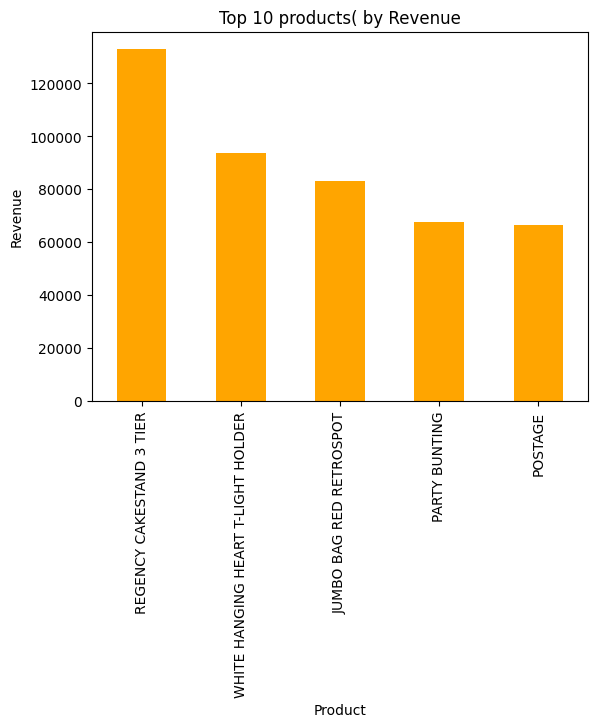

In [13]:
## Sales Trend Analysis
#Analyzing how revenue changes over time.

top_products.head(5).plot(kind = 'bar', color= 'orange')
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Top 10 products( by Revenue")
plt.show()


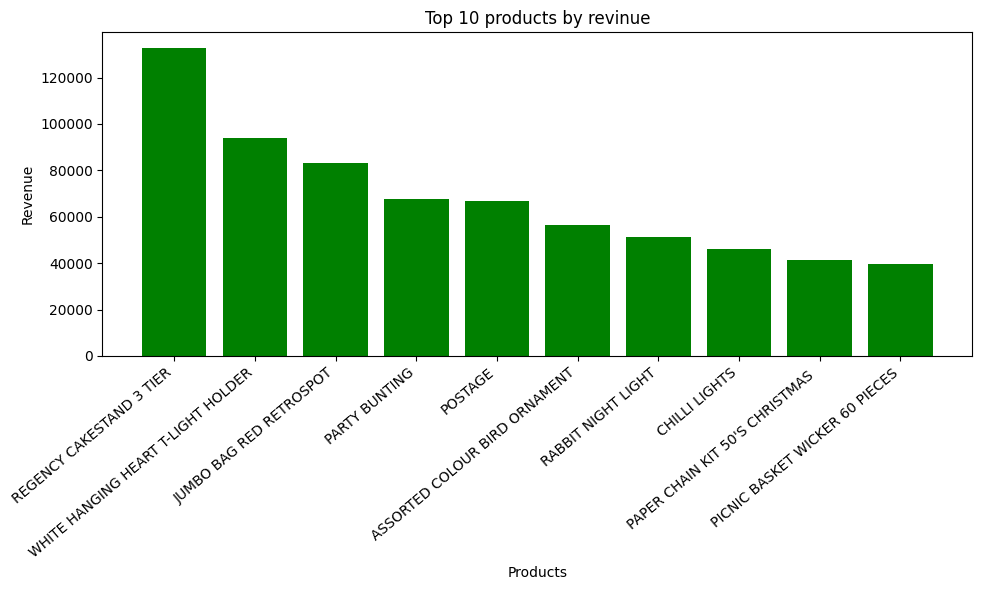

In [14]:
top10 = top_products.head(10)

plt.figure(figsize=(10,6) )
plt.bar(top10.index,top10.values,color = 'green')
plt.xticks(rotation = 40,ha = 'right')
plt.title("Top 10 products by revinue")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

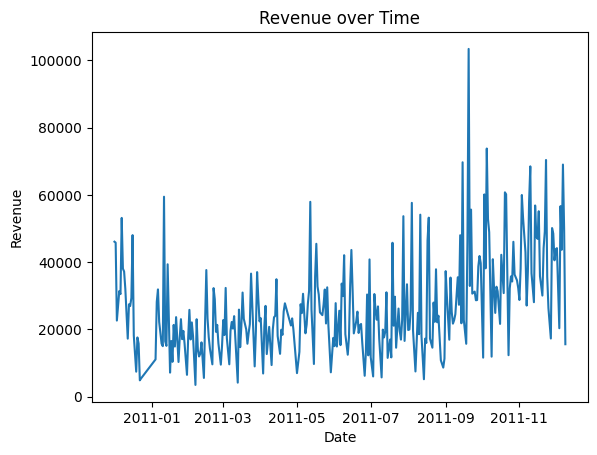

In [15]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])

sales_trend = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum()

sales_trend.plot()
plt.title("Revenue over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

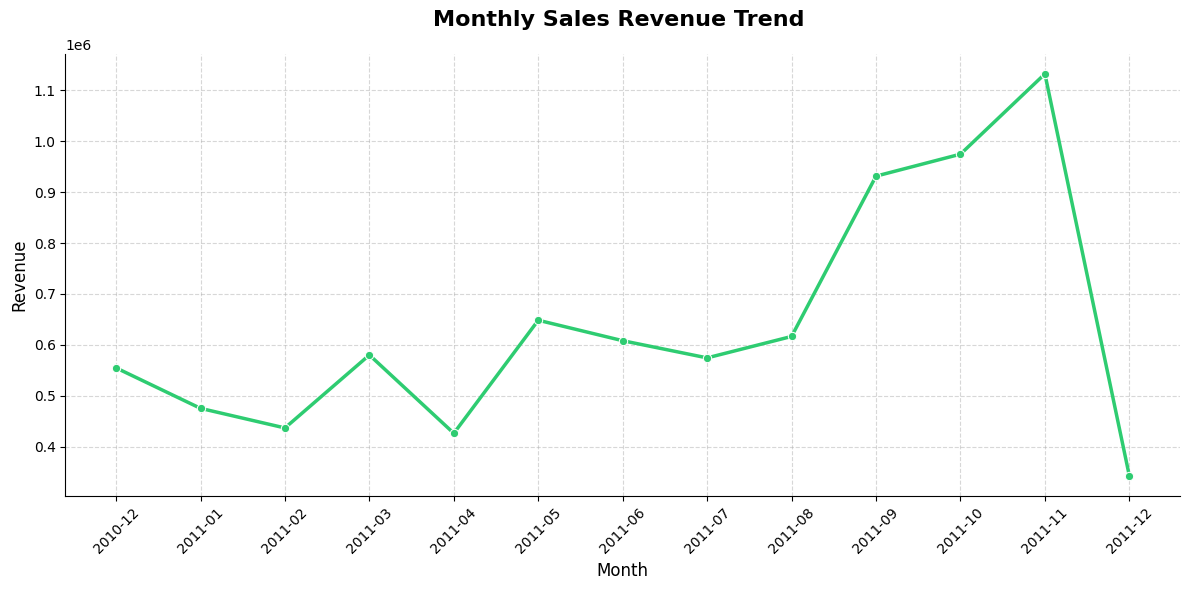

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Revenue'].sum()


monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df['Month'] = monthly_sales_df['Month'].astype(str)

# 2. Create the visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales_df, x='Month', y='Revenue', marker='o', color='#2ecc71', linewidth=2.5)

# 3. Add styling and labels
plt.title('Monthly Sales Revenue Trend ', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Clean the chart (Remove unnecessary borders)
sns.despine()

plt.tight_layout()
plt.show()

# Revenue peaks in November 2011, indicating strong seasonal demand.
# December shows lower revenue due to incomplete data (only 9 days available).
# Overall, sales show fluctuations with clear peak periods rather than steady growth.


In [17]:
monthly_sales.sort_values(ascending=False).head()


Month
2011-11    1132407.740
2011-10     974603.590
2011-09     931440.372
2011-05     648251.080
2011-08     616368.000
Freq: M, Name: Revenue, dtype: float64

In [18]:
monthly_sales.sort_values().head()

Month
2011-12    342506.380
2011-04    426047.851
2011-02    436546.150
2011-01    475074.380
2010-12    554604.020
Freq: M, Name: Revenue, dtype: float64

In [19]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [20]:

df['Day'] = df['InvoiceDate'].dt.day
dec_data = df[(df['InvoiceDate'].dt.month == 12) & (df['InvoiceDate'].dt.year == 2011)]

dec_avg = dec_data['Revenue'].sum() / dec_data['Day'].nunique()

dec_avg

np.float64(42813.2975)

In [21]:

monthly_avg = df.groupby(df['InvoiceDate'].dt.to_period('M')).apply(
    lambda x: x['Revenue'].sum() / x['InvoiceDate'].dt.day.nunique()
)

monthly_avg.sort_values(ascending=False).head()

InvoiceDate
2011-11    43554.143846
2011-12    42813.297500
2011-10    37484.753462
2011-09    35824.629692
2010-12    27730.201000
Freq: M, dtype: float64

In [22]:
# Country-wise Analysis
#Understanding revenue distribution across different countries.

In [23]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
top_countries.head(10)

# Insight:
# The revenue distribution is highly concentrated in the United Kingdom,
# which contributes the majority of total sales. This shows that the business
# is heavily dependent on a single market.
# Other countries like the Netherlands, EIRE, Germany, and France also contribute
# to revenue, but at a much smaller scale. This indicates an opportunity to expand
# and strengthen the business in these regions.
# Focusing on international markets can help reduce dependency on the UK
# and lead to more balanced and sustainable growth.

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

In [24]:
# Summary of Final Findings

summary = {
    "Total Revenue": df['Revenue'].sum(),
    "Unique Customers": df['CustomerID'].nunique(),
    "Best Performing Country": df.groupby('Country')['Revenue'].sum().idxmax(),
    "Average Order Value": df['Revenue'].mean()
}
for key, value in summary.items():
    print(f"{key}: {value}")


Total Revenue: 8300065.813999999
Unique Customers: 4372
Best Performing Country: United Kingdom
Average Order Value: 20.401853884555916


In [25]:
# Conclusion
#Summarizing key findings and business insights.

In [26]:
# This analysis focused on understanding sales performance using an e-commerce dataset.
# After cleaning the data and creating a revenue feature, key patterns were identified
# through product, time, and country-based analysis.
# 
# The business shows strong performance in decorative and gift-related products,
# indicating customer preference for aesthetic and lifestyle items.
# Monthly trend analysis revealed peak sales in November, suggesting seasonal demand,
# while December data was incomplete and handled carefully to avoid incorrect conclusions.
# 
# Revenue is highly concentrated in the United Kingdom, showing market dependency,
# but also highlighting opportunities for expansion in other countries.
# 
# Overall, this analysis provides useful insights that can help improve marketing strategies,
# inventory planning, and business growth decisions.